# Classifier Training

Train a classifier (ML) to detect familiar/unfamiliar face viewing based on ERP component statistical features.  

Classifiers to test:
- Support Vector Machine (SVM) 
- K Nearest Neighbors (KNN)
- Logistic Regression (strong baseline)
- Random Forest
- Convolutional Neural Network (CNN) *massive datasets are preferred*
- Recurrent Neural Network (RNN) *massive datasets are preferred*

In [131]:
## Config
k_fold_cv = 5  # cross-validation splits/folds
custom_class_weight = {0: 1, 1: 2}  # ratio of familiar : unfamiliar weighting
test_size = 0.2  # proportion of data to use for testing
metric_weights = {"recall": 2, "accuracy": 1}  # for permutation importance
save_models = False  # Set to False to skip saving models and scalers

# Per-experiment sample weights: higher value = more influence during training.
# Experiments 7 and 8 use finalized headgear, so they are emphasised.
exp_sample_weights = {'3': 1, '5': 1, '6A': 1.0, '6B': 1.0, '7': 1, '8': 1}


## 1. Load and Preprocess Data

In [117]:
## Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
import joblib

### Load Data

Load csv data with extracted features.

In [133]:
## Load data from multiple experiments/runs
# Experiments: 3, 5, 6, 7, 8
# Runs: A, B

experiments_to_load = ['3', '5', '6A', '6B', '7', '7', '7', '8', '8']  

def load_experiment_data(experiments_list):
    """Load and concatenate data from multiple experiments/runs."""
    data_frames = []
    
    for exp in experiments_list:
        # Determine the directory (based on experiment number, not the run letter)
        exp_number = ''.join(filter(str.isdigit, exp))
        data_dir = f'experiment_data/exp{exp_number}/'
        
        # Construct file name (includes run letter if present)
        file_name = f'erp_exp{exp}_features.csv'
        file_path = data_dir + file_name
        
        try:
            df = pd.read_csv(file_path)
            df['experiment'] = exp  # Add column to track which experiment the data came from
            data_frames.append(df)
            print(f"Loaded {exp}: {file_path} (shape: {df.shape})")
        except FileNotFoundError:
            print(f"Warning: File not found - {file_path}")
    
    # Concatenate all data frames
    if data_frames:
        data = pd.concat(data_frames, ignore_index=True)
        print(f"\nCombined data shape: {data.shape}")
        return data
    else:
        raise ValueError("No data files were successfully loaded.")

data = load_experiment_data(experiments_to_load)

Loaded 3: experiment_data/exp3/erp_exp3_features.csv (shape: (77, 74))
Loaded 5: experiment_data/exp5/erp_exp5_features.csv (shape: (46, 74))
Loaded 6A: experiment_data/exp6/erp_exp6A_features.csv (shape: (35, 74))
Loaded 6B: experiment_data/exp6/erp_exp6B_features.csv (shape: (46, 74))
Loaded 7: experiment_data/exp7/erp_exp7_features.csv (shape: (76, 74))
Loaded 7: experiment_data/exp7/erp_exp7_features.csv (shape: (76, 74))
Loaded 7: experiment_data/exp7/erp_exp7_features.csv (shape: (76, 74))
Loaded 8: experiment_data/exp8/erp_exp8_features.csv (shape: (35, 74))
Loaded 8: experiment_data/exp8/erp_exp8_features.csv (shape: (35, 74))

Combined data shape: (502, 74)


In [134]:
## Data info
print("ERP Feature Data Info:")
print(data.info())
print(data.head())

ERP Feature Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 74 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   condition         502 non-null    object 
 1   Cz_mean           502 non-null    float64
 2   Cz_median         502 non-null    float64
 3   Cz_max            502 non-null    float64
 4   Cz_min            502 non-null    float64
 5   Cz_ptp            502 non-null    float64
 6   Cz_std            502 non-null    float64
 7   Cz_skew           502 non-null    float64
 8   Cz_auc            502 non-null    float64
 9   Cz_kurtosis       502 non-null    float64
 10  Pz_mean           502 non-null    float64
 11  Pz_median         502 non-null    float64
 12  Pz_max            502 non-null    float64
 13  Pz_min            502 non-null    float64
 14  Pz_ptp            502 non-null    float64
 15  Pz_std            502 non-null    float64
 16  Pz_skew           502

In [135]:
## Show distribution of data across experiments
if 'experiment' in data.columns:
    print("\nData distribution across experiments:")
    print(data['experiment'].value_counts().sort_index())
    print("\nClass distribution by experiment:")
    print(data.groupby(['experiment', 'condition']).size().unstack(fill_value=0))


Data distribution across experiments:
experiment
3      77
5      46
6A     35
6B     46
7     228
8      70
Name: count, dtype: int64

Class distribution by experiment:
condition   Fam  Mov  Unf
experiment               
3            39    0   38
5            23    0   23
6A           16    3   16
6B           23    0   23
7           108    9  111
8            38    0   32


### Preprocessing

1. Re-label class labels (0 for familiar, 1 for unfamiliar) and remove 'move' types 
2. Remove outliers (if any)
3. Scale/normalize (StandardScaler)

In [136]:
## Relabel class labels
# Store experiment column before filtering
experiment_col = data['experiment'].copy() if 'experiment' in data.columns else None

# Filter out 'Mov' rows first
data = data[data['condition'].isin(['Fam', 'Unf'])]

# Map string labels to binary (0 - familiar, 1 - unfamiliar)
data['condition'] = data['condition'].map({'Fam': 0, 'Unf': 1})
data = data.rename(columns={'condition': 'IS_UNFAMILIAR'})

# Re-add experiment column if it existed
if experiment_col is not None:
    # Filter experiment column to match filtered data indices
    data['experiment'] = experiment_col[data.index]

print("Relabeled ERP Feature Data Info:")
print(data.head())

Relabeled ERP Feature Data Info:
   IS_UNFAMILIAR    Cz_mean  Cz_median     Cz_max     Cz_min     Cz_ptp  \
0              0  26.764760  24.362443  58.039779  -2.400666  60.440445   
1              1  -4.156202  -8.651524  31.375126 -32.242344  63.617470   
2              0 -10.236204 -10.681199  27.542099 -42.344200  69.886299   
3              1 -22.921269 -29.888542  -1.674582 -40.691204  39.016622   
4              0  12.025607  12.909037  26.858914 -11.233996  38.092910   

      Cz_std   Cz_skew    Cz_auc  Cz_kurtosis  ...  P300avg_mean  \
0  16.496948  0.087932  2.657336     2.062226  ...     -0.724392   
1  18.717124  0.573394 -0.454795     2.360514  ...     -0.301335   
2  19.690413  0.113310 -1.031981     2.170020  ...      7.824398   
3  14.970698  0.317774 -2.297291     1.239246  ...     -5.435706   
4   9.482324 -0.897700  1.208392     3.781252  ...     -4.931935   

   P300avg_median  P300avg_max  P300avg_min  P300avg_ptp  P300avg_std  \
0       -6.485378    37.403066   -

In [137]:
## Prepare data
# Exclude the experiment column and the target variable from features
X = data.drop(columns=['IS_UNFAMILIAR'] + ([col for col in data.columns if col == 'experiment'] if 'experiment' in data.columns else []))
y = data['IS_UNFAMILIAR']

# Split data into training and testing sets
# stratify=y ensures the familiar/unfamiliar ratio is preserved in both splits
if test_size > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
else:
    X_train, y_train = X, y
    X_test, y_test = pd.DataFrame(), pd.Series()  # Empty test sets

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")
if 'experiment' in data.columns:
    print(f"Experiments included: {data['experiment'].unique()}")
if test_size > 0:
    print(f"\nClass distribution in test set:")
    print(y_test.value_counts().rename({0: 'Familiar', 1: 'Unfamiliar'}))
    print(f"Class distribution in training set:")
    print(y_train.value_counts().rename({0: 'Familiar', 1: 'Unfamiliar'}))


Training set shape: (392, 72)
Test set shape: (98, 72)
Training target shape: (392,)
Test target shape: (98,)
Experiments included: ['3' '5' '6A' '6B' '7' '8']

Class distribution in test set:
IS_UNFAMILIAR
Familiar      49
Unfamiliar    49
Name: count, dtype: int64
Class distribution in training set:
IS_UNFAMILIAR
Familiar      198
Unfamiliar    194
Name: count, dtype: int64


In [138]:
## Compute per-sample training weights based on experiment
# Uses exp_sample_weights from Config; experiments 7 and 8 get higher weight.
if 'experiment' in data.columns:
    exp_weight_series = data.loc[X_train.index, 'experiment'].map(exp_sample_weights).fillna(1.0)
    sample_weight_train = exp_weight_series.values.astype(float)
    print("Sample weight distribution (weight → sample count):")
    for w, grp in exp_weight_series.groupby(exp_weight_series):
        print(f"  weight {w:.1f} → {len(grp)} samples")
else:
    sample_weight_train = None
    print("No experiment column found; sample weights not applied.")


Sample weight distribution (weight → sample count):
  weight 1.0 → 392 samples


In [139]:
## Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
if test_size > 0:
    X_test_scaled = scaler.transform(X_test)

print("Scaled ERP Feature Data Info:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Scaled ERP Feature Data Info:
    Cz_mean  Cz_median    Cz_max    Cz_min    Cz_ptp    Cz_std   Cz_skew  \
0 -1.293095  -1.085412 -1.117129 -1.318889  0.029505  0.073383 -1.766523   
1  0.116585   0.177526 -0.335585  0.512340 -0.674984 -0.635795 -1.242454   
2 -0.161807  -0.156140 -0.568008  0.435755 -0.817739 -0.852518  1.028628   
3 -0.520838  -0.484671 -0.193761 -0.572594  0.263922  0.194278  0.109406   
4  0.587039   0.630406  0.387823  0.560179 -0.087254 -0.055987 -0.046163   

     Cz_auc  Cz_kurtosis   Pz_mean  ...  N250avg_kurtosis  P300avg_mean  \
0 -1.287785     0.545911 -1.303920  ...         -0.078375     -1.394633   
1  0.120309    -0.649307  0.152532  ...          0.632316      0.143422   
2 -0.164410     0.752021 -0.040598  ...          0.299583     -0.112540   
3 -0.508419     0.251249 -0.435411  ...          0.049792     -0.516337   
4  0.589599    -0.542933  0.810550  ...         -0.578175      0.743666   

   P300avg_median  P300avg_max  P300avg_min  P300avg_ptp  P300

In [140]:
## Save feature scaler to file
if save_models:
    dir = 'models/'
    scaler_filename = dir + 'erp_feature_scaler.joblib'
    joblib.dump(scaler, scaler_filename)
    print(f"Feature scaler saved to: {scaler_filename}")

## 2. Train ML Classifier Models

In [126]:
## Imports
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
import seaborn as sns
import joblib

### 2.0 Helper Functions

In [62]:
def cross_validate_with_folds(model, X, y, n_splits, scoring, sample_weight=None):
    """Perform cross validation with specified number of folds and return detailed results.

    When sample_weight is provided and the model supports it, folds are iterated
    manually so that only the training-fold weights are passed to fit() — passing
    the full weight array via fit_params would silently apply the wrong weights.
    """
    import inspect
    from sklearn.base import clone

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    supports_sw = "sample_weight" in inspect.signature(model.fit).parameters

    if sample_weight is not None and not supports_sw:
        print(f"  (Note: {type(model).__name__} does not support sample_weight; weights ignored in CV)")

    if sample_weight is not None and supports_sw:
        # Manual fold iteration — correctly subsets weights to each training fold
        fold_accuracies, fold_recalls = [], []
        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
            y_val = y.iloc[val_idx] if hasattr(y, "iloc") else y[val_idx]
            w_tr = sample_weight[train_idx]
            fold_model = clone(model)
            fold_model.fit(X_tr, y_tr, sample_weight=w_tr)
            fold_accuracies.append(accuracy_score(y_val, fold_model.predict(X_val)))
            fold_recalls.append(recall_score(y_val, fold_model.predict(X_val)))
        cv_results = {
            "test_accuracy": np.array(fold_accuracies),
            "test_recall": np.array(fold_recalls),
        }
    else:
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=scoring,
            return_train_score=True,
        )

    print("\nCross-Validation Results:")
    print(
        f"CV Accuracy: {cv_results['test_accuracy'].mean():.3f} (+/- {cv_results['test_accuracy'].std() * 2:.3f})"
    )
    print(
        f"CV Recall: {cv_results['test_recall'].mean():.3f} (+/- {cv_results['test_recall'].std() * 2:.3f})"
    )

    print("\nPer-Fold Results:")
    for fold in range(n_splits):
        print(
            f"  Fold {fold + 1}: Accuracy={cv_results['test_accuracy'][fold]:.3f}, "
            f"Recall={cv_results['test_recall'][fold]:.3f}"
        )
    return cv_results


In [63]:
def evaluate_train_and_cv(
    name,
    model,
    X_train,
    y_train,
    n_splits,
    scoring=("accuracy", "recall"),
    detailed_train_report=False,
    sample_weight=None,
):
    """Train the model, evaluate on training set, and perform cross-validation with detailed results."""
    import inspect

    if isinstance(model, (tuple, list)):
        model = model[0]

    supports_sw = "sample_weight" in inspect.signature(model.fit).parameters

    if sample_weight is not None and supports_sw:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)

    y_train_pred = None
    if hasattr(model, "predict"):
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        train_recall = recall_score(y_train, y_train_pred)
    else:
        train_accuracy = model.score(X_train, y_train)
        train_recall = np.nan

    print("=" * 50)
    print("Model Training and Evaluation")
    print("=" * 50)

    print(f"Data Count: {len(y_train)}")
    print(f"{name} Training Accuracy: {train_accuracy:.3f}")
    if np.isnan(train_recall):
        print(f"{name} Training Recall: N/A (no predict method)")
    else:
        print(f"{name} Training Recall: {train_recall:.3f}")

    cv_results = cross_validate_with_folds(model, X_train, y_train, n_splits, scoring, sample_weight=sample_weight)

    if detailed_train_report and y_train_pred is not None:
        print("\nDetailed Training Classification Report:")
        print(classification_report(y_train, y_train_pred, target_names=['Familiar', 'Unfamiliar']))

        print("Confusion Matrix (Train):")
        cm = confusion_matrix(y_train, y_train_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Familiar', 'Unfamiliar'])
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"{name} Confusion Matrix (Train)")
        plt.show()
    elif detailed_train_report:
        print("\nDetailed Training Report skipped (no predict method)")

    return model, cv_results


In [64]:
def evaluate_test_set(name, model, X_test, y_test):
    """Evaluate performance on the test set and display classification report and confusion matrix."""
    if isinstance(model, (tuple, list)):
        model = model[0]

    y_test_pred = None
    if hasattr(model, "predict"):
        y_test_pred = model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_recall = recall_score(y_test, y_test_pred)
    else:
        test_accuracy = model.score(X_test, y_test)
        test_recall = np.nan

    print("=" * 50)
    print("Test Set Evaluation")
    print("=" * 50)

    print(f"Data Count: {len(y_test)}")
    print(f"{name} Test Accuracy: {test_accuracy:.3f}")
    if np.isnan(test_recall):
        print(f"{name} Test Recall: N/A (no predict method)")
    else:
        print(f"{name} Test Recall: {test_recall:.3f}")

    if y_test_pred is None:
        print("\nTest Classification Report skipped (no predict method)")
        print("Test Confusion Matrix skipped (no predict method)")
        return

    print("\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=['Familiar', 'Unfamiliar']))
    print("Test Confusion Matrix:")
    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(
        confusion_matrix=cm_test,
        display_labels=['Familiar', 'Unfamiliar'],
    )
    disp_test.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix (Test)")
    plt.show()

### 2.1 SVM Classifier

Model Training and Evaluation
Data Count: 392
SVM Training Accuracy: 0.862
SVM Training Recall: 1.000

Cross-Validation Results:
CV Accuracy: 0.758 (+/- 0.129)
CV Recall: 0.913 (+/- 0.083)

Per-Fold Results:
  Fold 1: Accuracy=0.835, Recall=0.974
  Fold 2: Accuracy=0.671, Recall=0.872
  Fold 3: Accuracy=0.782, Recall=0.897
  Fold 4: Accuracy=0.692, Recall=0.872
  Fold 5: Accuracy=0.808, Recall=0.947

Detailed Training Classification Report:
              precision    recall  f1-score   support

    Familiar       1.00      0.73      0.84       198
  Unfamiliar       0.78      1.00      0.88       194

    accuracy                           0.86       392
   macro avg       0.89      0.86      0.86       392
weighted avg       0.89      0.86      0.86       392

Confusion Matrix (Train):


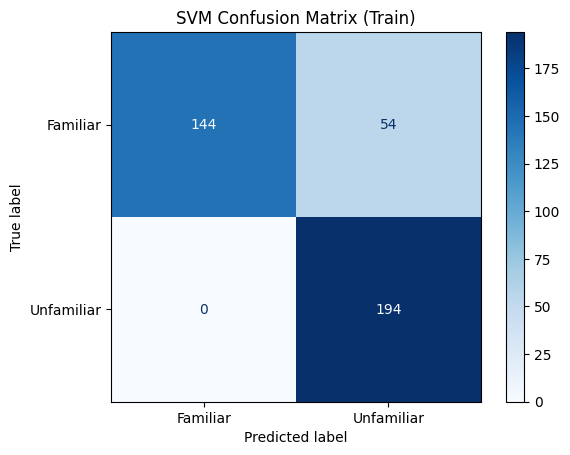

In [141]:
## Train and evaluate SVM
# Params:
# kernel: rbf (default), linear, poly, sigmoid
# C (regularization parameter): default=1.0
# gamma (kernel coefficient): scale (default), auto, or float value ()
# class_weight (weight of classes): None (default), 'balanced', or dict

svm = SVC(kernel='rbf', C=11, gamma='scale', random_state=42, class_weight=custom_class_weight)
svm, _ = evaluate_train_and_cv("SVM", svm, X_train_scaled, y_train, k_fold_cv, detailed_train_report=True, sample_weight=sample_weight_train)


Test Set Evaluation
Data Count: 98
SVM Test Accuracy: 0.765
SVM Test Recall: 0.898

Test Classification Report:
              precision    recall  f1-score   support

    Familiar       0.86      0.63      0.73        49
  Unfamiliar       0.71      0.90      0.79        49

    accuracy                           0.77        98
   macro avg       0.79      0.77      0.76        98
weighted avg       0.79      0.77      0.76        98

Test Confusion Matrix:


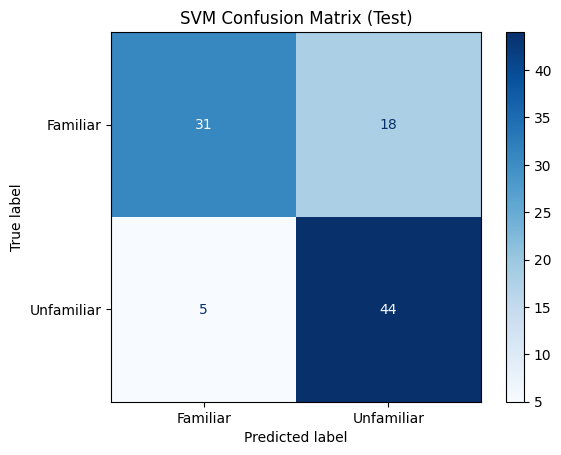

In [142]:
## Final held-out test evaluation
evaluate_test_set("SVM", svm, X_test_scaled, y_test)

In [ ]:
## Save SVM model to file
dir = 'models/'
model_filename = 'erp_svm_model.joblib'
joblib.dump(svm, dir + model_filename)
print(f"SVM model saved to: {dir + model_filename}")

SVM model saved to: models/erp_svm_model.joblib


#### Plot Decision Boundary for Different Kernels

Use PCA to represent the data in the two major components. 

Then, train SVC model and plot decision boundaries. Identify which kernel has the best performance.

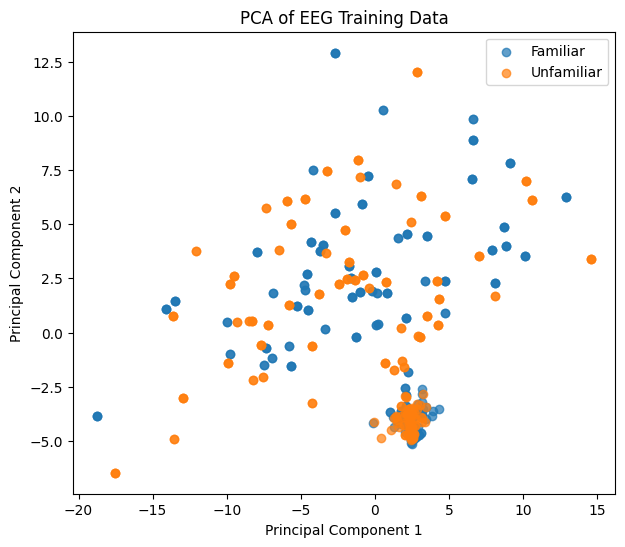

In [17]:
## PCA to 2D for visualization 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot PCA results
plt.figure(figsize=(7, 6))
class_labels = ['Familiar', 'Unfamiliar']
for label in np.unique(y_train):
    plt.scatter(X_train_pca[y_train == label, 0], X_train_pca[y_train == label, 1], label=class_labels[label], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of EEG Training Data')
plt.legend()
plt.show()

In [18]:
## Function to plot decision boundaries
def plot_training_data_with_decision_boundary(
    kernel, ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = SVC(kernel=kernel, gamma=2, class_weight=custom_class_weight).fit(X_train_pca, y_train)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -10, 10, -5, 5
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X_train_pca, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="IS_UNFAMILIAR")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()
        
    # Classifier accuracy info
    y_train_pred = clf.predict(X_train_pca)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    print(f"{kernel} Kernel Training Accuracy: {train_accuracy:.3f}")
    print(f"{kernel} Kernel Training Recall: {train_recall:.3f}")
    # Number of correct predictions
    correct_predictions = (y_train == y_train_pred).sum()
    print(f"Number of correct predictions: {correct_predictions} out of {len(y_train)}")

linear Kernel Training Accuracy: 0.496
linear Kernel Training Recall: 1.000
Number of correct predictions: 243 out of 490


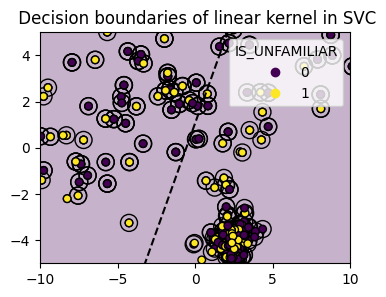

In [49]:
plot_training_data_with_decision_boundary("linear")

In [ ]:
plot_training_data_with_decision_boundary("poly")

rbf Kernel Training Accuracy: 0.804
rbf Kernel Training Recall: 1.000
Number of correct predictions: 394 out of 490


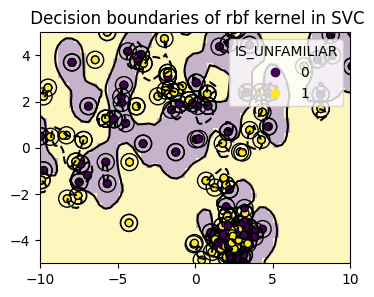

In [19]:
plot_training_data_with_decision_boundary("rbf")

sigmoid Kernel Training Accuracy: 0.428
sigmoid Kernel Training Recall: 0.560
Number of correct predictions: 86 out of 201


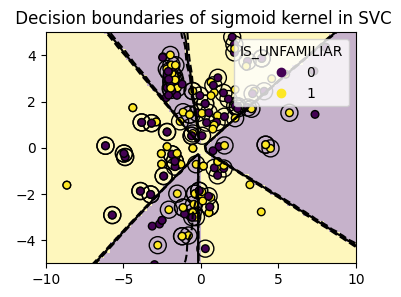

In [29]:
plot_training_data_with_decision_boundary("sigmoid")

Based on these results, rbf is most well-suited for the decision in this task. Although, it could be overfitting.

### 2.2 K-Nearest Neighbors (KNN)

Model Training and Evaluation
Data Count: 490
KNN Training Accuracy: 0.576
KNN Training Recall: 0.638
  (Note: KNeighborsClassifier does not support sample_weight; weights ignored in CV)

Cross-Validation Results:
CV Accuracy: 0.553 (+/- 0.110)
CV Recall: 0.610 (+/- 0.119)

Per-Fold Results:
  Fold 1: Accuracy=0.571, Recall=0.625
  Fold 2: Accuracy=0.612, Recall=0.708
  Fold 3: Accuracy=0.571, Recall=0.571
  Fold 4: Accuracy=0.561, Recall=0.612
  Fold 5: Accuracy=0.449, Recall=0.531

Detailed Training Classification Report:
              precision    recall  f1-score   support

    Familiar       0.59      0.51      0.55       247
  Unfamiliar       0.56      0.64      0.60       243

    accuracy                           0.58       490
   macro avg       0.58      0.58      0.57       490
weighted avg       0.58      0.58      0.57       490

Confusion Matrix (Train):


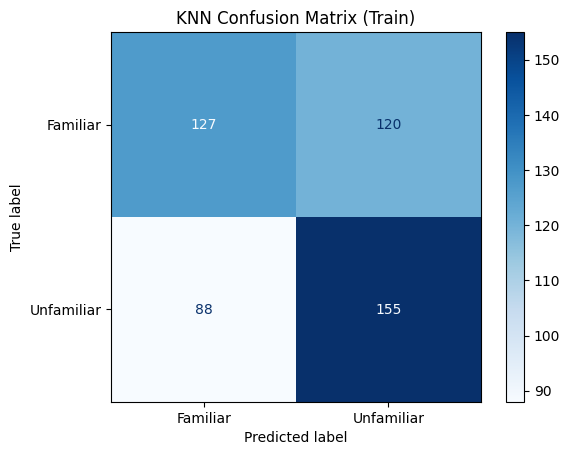

In [20]:
## Train KNN Classifier
# Note: KNeighborsClassifier does not support sample_weight; the weight is noted but ignored.

# Full dataset
knn = evaluate_train_and_cv("KNN", KNeighborsClassifier(n_neighbors=25), X_train_scaled, y_train, k_fold_cv, detailed_train_report=True, sample_weight=sample_weight_train)

# Reduced dataset
# knn = evaluate_train_and_cv("KNN (reduced)", KNeighborsClassifier(n_neighbors=7), X_train_reduced_scaled, y_train, k_fold_cv, detailed_train_report=True, sample_weight=sample_weight_train)


Test Set Evaluation
Data Count: 31
KNN Test Accuracy: 0.613
KNN Test Recall: 0.875

Test Classification Report:
              precision    recall  f1-score   support

    Familiar       0.71      0.33      0.45        15
  Unfamiliar       0.58      0.88      0.70        16

    accuracy                           0.61        31
   macro avg       0.65      0.60      0.58        31
weighted avg       0.65      0.61      0.58        31

Test Confusion Matrix:


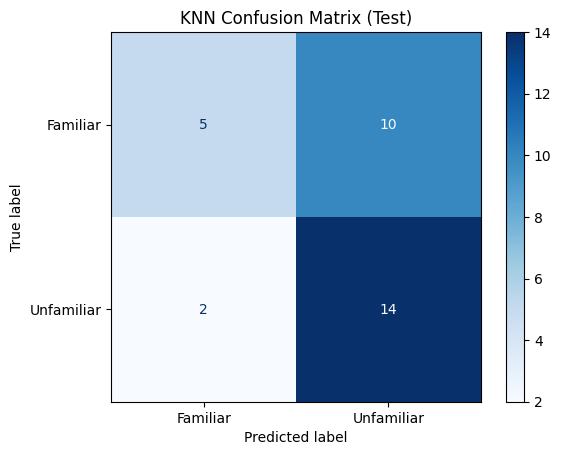

In [243]:
## Evaluate KNN on test set
evaluate_test_set("KNN", knn, X_test_scaled, y_test)

### 2.3 Logistic Regression

Model Training and Evaluation
Data Count: 490
LogReg Training Accuracy: 0.602
LogReg Training Recall: 0.942

Cross-Validation Results:
CV Accuracy: 0.539 (+/- 0.076)
CV Recall: 0.868 (+/- 0.099)

Per-Fold Results:
  Fold 1: Accuracy=0.510, Recall=0.875
  Fold 2: Accuracy=0.510, Recall=0.771
  Fold 3: Accuracy=0.612, Recall=0.898
  Fold 4: Accuracy=0.531, Recall=0.898
  Fold 5: Accuracy=0.531, Recall=0.898

Detailed Training Classification Report:
              precision    recall  f1-score   support

    Familiar       0.82      0.27      0.40       247
  Unfamiliar       0.56      0.94      0.70       243

    accuracy                           0.60       490
   macro avg       0.69      0.60      0.55       490
weighted avg       0.69      0.60      0.55       490

Confusion Matrix (Train):


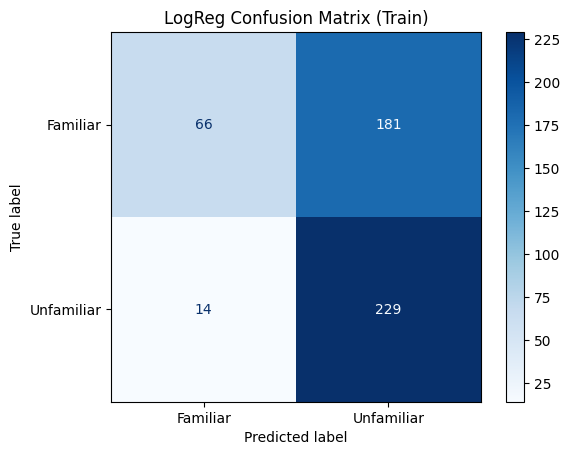

In [21]:
## Train Logistic Regression Classifier
# Params:
# max_iter: maximum number of iterations for convergence (default=100)
# solver: algorithm to use in optimization (default='lbfgs', other options include 'liblinear', 'sag', 'saga', 'newton-cg')

# Full dataset
logreg, _ = evaluate_train_and_cv(
    "LogReg",
    LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, class_weight=custom_class_weight),
    X_train_scaled,
    y_train,
    k_fold_cv,
    detailed_train_report=True,
    sample_weight=sample_weight_train,
 )
# Reduced dataset
# logreg_reduced, _ = evaluate_train_and_cv(
#     "LogReg (Reduced)",
#     LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, class_weight=custom_class_weight),
#     X_train_reduced_scaled,
#     y_train,
#     k_fold_cv,
#     detailed_train_report=True,
#     sample_weight=sample_weight_train,
# )


Test Set Evaluation
Data Count: 31
LogReg Test Accuracy: 0.548
LogReg Test Recall: 0.812

Test Classification Report:
              precision    recall  f1-score   support

    Familiar       0.57      0.27      0.36        15
  Unfamiliar       0.54      0.81      0.65        16

    accuracy                           0.55        31
   macro avg       0.56      0.54      0.51        31
weighted avg       0.56      0.55      0.51        31

Test Confusion Matrix:


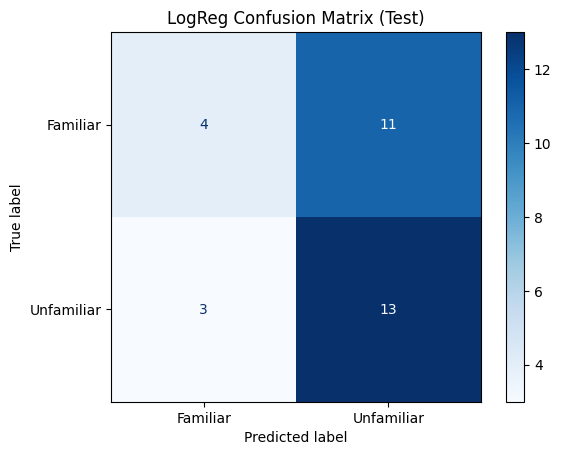

In [257]:
## Evaluate LogReg on test set
evaluate_test_set("LogReg", logreg, X_test_scaled, y_test)

### 2.4 Random Forest

Model Training and Evaluation
Data Count: 392
RF Training Accuracy: 0.732
RF Training Recall: 1.000

Cross-Validation Results:
CV Accuracy: 0.641 (+/- 0.089)
CV Recall: 0.938 (+/- 0.110)

Per-Fold Results:
  Fold 1: Accuracy=0.608, Recall=1.000
  Fold 2: Accuracy=0.582, Recall=0.872
  Fold 3: Accuracy=0.628, Recall=0.872
  Fold 4: Accuracy=0.692, Recall=0.974
  Fold 5: Accuracy=0.692, Recall=0.974

Detailed Training Classification Report:
              precision    recall  f1-score   support

    Familiar       1.00      0.47      0.64       198
  Unfamiliar       0.65      1.00      0.79       194

    accuracy                           0.73       392
   macro avg       0.82      0.73      0.71       392
weighted avg       0.83      0.73      0.71       392

Confusion Matrix (Train):


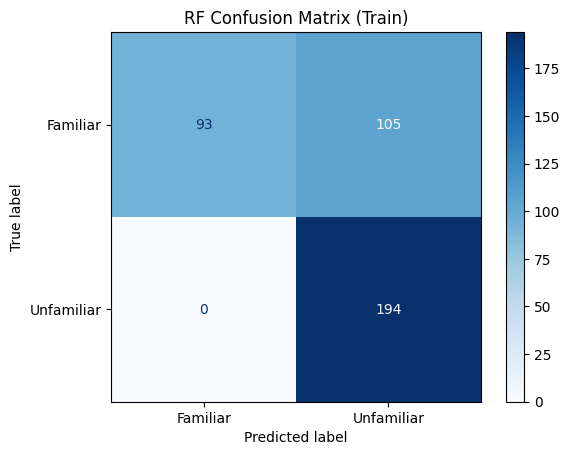

In [64]:
## Train Random Forest Classifier
# Params:
# n_estimators: number of trees in the forest (default=100)
# criterion: function to measure the quality of a split (default='gini', others: 'entropy', 'log_loss')
# max_depth: maximum depth of the tree (default = None)
# min_samples_split: minimum number of samples required to split an internal node (default=2)
# min_samples_leaf: minimum number of samples required to be at a leaf node (default=1)

# Full dataset
rf, _ = evaluate_train_and_cv(
    "RF",
    RandomForestClassifier(
        n_estimators=500, 
        criterion = 'gini',
        max_depth=8,
        min_samples_split=3,
        min_samples_leaf=1,
        random_state=42, n_jobs=-1, class_weight=custom_class_weight),
    X_train_scaled,
    y_train,
    k_fold_cv,
    detailed_train_report=True,
    sample_weight=sample_weight_train,
 )


Test Set Evaluation
Data Count: 98
RF Test Accuracy: 0.796
RF Test Recall: 0.898

Test Classification Report:
              precision    recall  f1-score   support

    Familiar       0.87      0.69      0.77        49
  Unfamiliar       0.75      0.90      0.81        49

    accuracy                           0.80        98
   macro avg       0.81      0.80      0.79        98
weighted avg       0.81      0.80      0.79        98

Test Confusion Matrix:


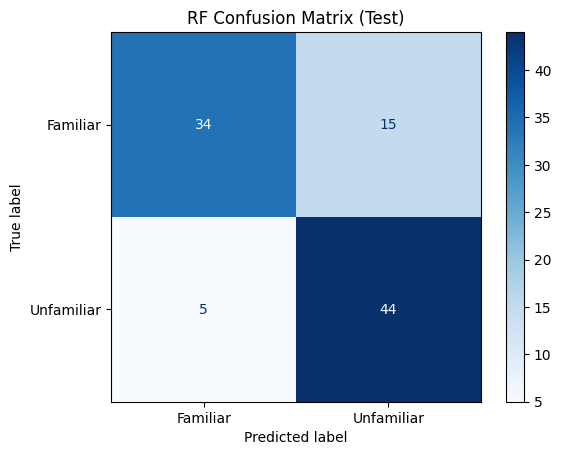

In [62]:
## Evaluate RF on test set
evaluate_test_set("RF", rf, X_test_scaled, y_test)

### 2.5 Linear Discriminant Analysis (LDA)

Model Training and Evaluation
Data Count: 490
LDA Training Accuracy: 0.712
LDA Training Recall: 0.671
  (Note: LinearDiscriminantAnalysis does not support sample_weight; weights ignored in CV)

Cross-Validation Results:
CV Accuracy: 0.618 (+/- 0.110)
CV Recall: 0.596 (+/- 0.259)

Per-Fold Results:
  Fold 1: Accuracy=0.582, Recall=0.521
  Fold 2: Accuracy=0.612, Recall=0.583
  Fold 3: Accuracy=0.571, Recall=0.429
  Fold 4: Accuracy=0.724, Recall=0.816
  Fold 5: Accuracy=0.602, Recall=0.633

Detailed Training Classification Report:
              precision    recall  f1-score   support

    Familiar       0.70      0.75      0.73       247
  Unfamiliar       0.73      0.67      0.70       243

    accuracy                           0.71       490
   macro avg       0.71      0.71      0.71       490
weighted avg       0.71      0.71      0.71       490

Confusion Matrix (Train):


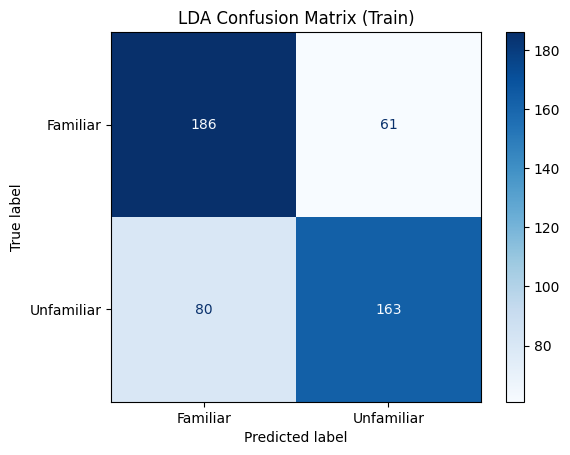

In [42]:
## Train LDA Classifier
# Solver: svd (default), lsqr, eigen
# shrinkage: None (default), 'auto', float value (0,1) - not supported with svd solver

# Full dataset
lda, _ = evaluate_train_and_cv(
    "LDA",
    LinearDiscriminantAnalysis(solver='svd', shrinkage=None),
    X_train_scaled,
    y_train,
    k_fold_cv,
    detailed_train_report=True,
    sample_weight=sample_weight_train,
 )


Test Set Evaluation
Data Count: 31
LDA Test Accuracy: 0.710
LDA Test Recall: 0.812

Test Classification Report:
              precision    recall  f1-score   support

    Familiar       0.75      0.60      0.67        15
  Unfamiliar       0.68      0.81      0.74        16

    accuracy                           0.71        31
   macro avg       0.72      0.71      0.70        31
weighted avg       0.72      0.71      0.71        31

Test Confusion Matrix:


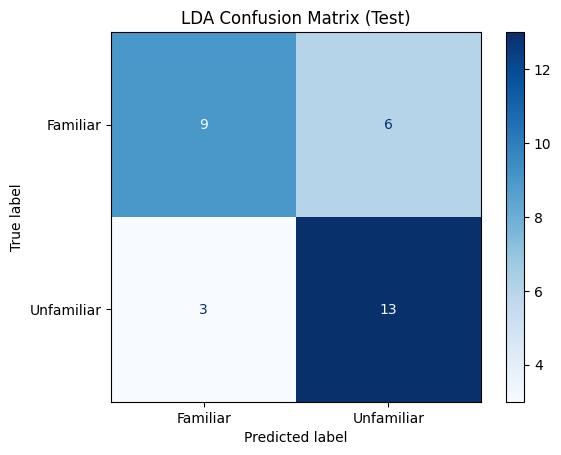

In [326]:
## Evaluate LDA on test set
evaluate_test_set("LDA", lda, X_test_scaled, y_test)

### 2.8 Evaluate Feature Importance

Evaluate the contribution of certain features depending on their permutation importance (effect on accuracy/recall when removing the feature).

In [67]:
def feature_importance_analysis(
    model,
    X_train_scaled,
    y_train,
    X_train,
    X_test_scaled=None,
    y_test=None,
    method="cv",
    metric_weights=None,
    n_repeats=10,
):
    """Feature importance via CV score drop or permutation importance on held-out test set."""
    if metric_weights is None:
        metric_weights = {"recall": 0.9, "accuracy": 0.7}

    def weighted_score(y_true, y_pred):
        recall = recall_score(y_true, y_pred)
        accuracy = accuracy_score(y_true, y_pred)
        return metric_weights["recall"] * recall + metric_weights["accuracy"] * accuracy

    from sklearn.metrics import make_scorer
    scorer = make_scorer(weighted_score)

    if method == "cv":
        skf = StratifiedKFold(n_splits=k_fold_cv, shuffle=True, random_state=42)
        baseline = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring=scorer).mean()

        importances = []
        for idx, col in enumerate(X_train.columns):
            X_drop = np.delete(X_train_scaled, idx, axis=1)
            score = cross_val_score(model, X_drop, y_train, cv=skf, scoring=scorer).mean()
            importances.append(baseline - score)

        importance_label = "CV weighted score drop"
    elif method == "permutation":
        perm = permutation_importance(
            model,
            X_test_scaled,
            y_test,
            n_repeats=n_repeats,
            random_state=4,
            scoring=scorer,
        )
        importances = perm.importances_mean
        importance_label = "Permutation importance (held-out test set)"
    else:
        raise ValueError("method must be 'cv' or 'permutation'")

    df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
    df['channel'] = df['feature'].str.split('_').str[0]
    df['stat'] = df['feature'].str.split('_').str[1]

    # Top features with 1-based ranks as the index (no duplicate numbering)
    num_features = 20
    topN = df.sort_values('importance', ascending=False).head(num_features).reset_index(drop=True)
    topN.index = np.arange(1, len(topN) + 1)
    topN.index.name = ''
    print(f"Top {num_features} Features ({importance_label}):")
    print(topN[['feature', 'importance']])

    # Channel importance
    print("\nChannel Importance:")
    print(df.groupby('channel')['importance'].sum().sort_values(ascending=False))

    # Statistical feature importance
    print("\nStatistical Feature Importance:")
    print(df.groupby('stat')['importance'].sum().sort_values(ascending=False))

    # Plot channel importances
    channel_importance = df.groupby('channel')['importance'].sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=channel_importance.index, y=channel_importance.values)
    plt.title(f"Channel Importance based on {importance_label}")
    plt.xlabel('Channel')
    plt.ylabel('Importance')
    plt.show()

    # Plot statistical feature importances
    stat_importance = df.groupby('stat')['importance'].sum().sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=stat_importance.index, y=stat_importance.values)
    plt.title(f"Statistical Feature Importance based on {importance_label}")
    plt.xlabel('Statistical Feature')
    plt.ylabel('Importance')
    plt.show()

Top 20 Features (Permutation importance (held-out test set)):
             feature  importance
                                
1             Cz_max    0.144898
2            O1_skew    0.125510
3        O2_kurtosis    0.121429
4        O1_kurtosis    0.110204
5        P7_kurtosis    0.110204
6            P7_skew    0.094898
7             O2_max    0.090816
8   N250avg_kurtosis    0.086735
9            Cz_mean    0.081633
10         Pz_median    0.075510
11       P8_kurtosis    0.073469
12       Pz_kurtosis    0.071429
13            Cz_auc    0.071429
14         Cz_median    0.071429
15           P8_skew    0.070408
16       Cz_kurtosis    0.068367
17           O2_skew    0.067347
18            P7_std    0.066327
19            O2_std    0.065306
20            P7_ptp    0.065306

Channel Importance:
channel
Cz         0.601020
O2         0.551020
P7         0.446939
P8         0.401020
O1         0.392857
Pz         0.307143
N250avg    0.271429
P300avg    0.193878
Name: importance, dtype

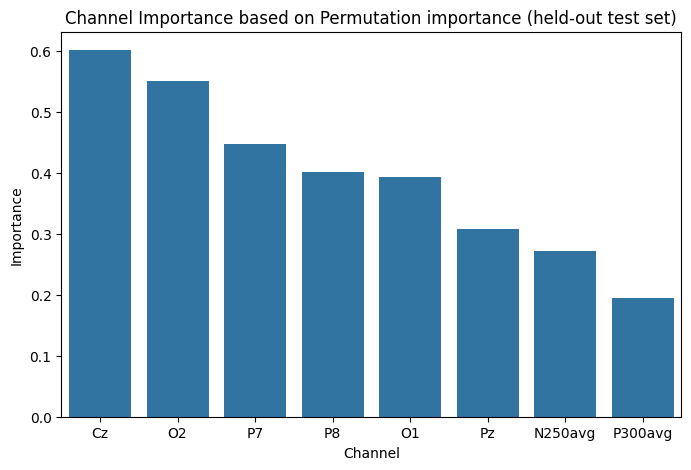

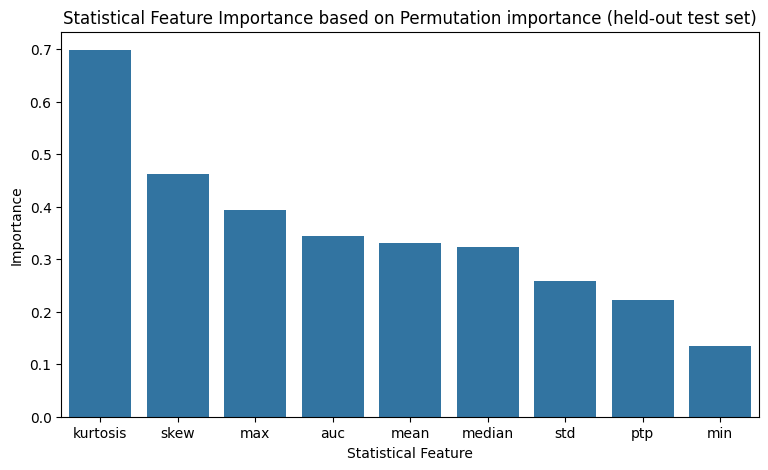

In [143]:
## SVM feature importance analysis
feature_importance_analysis(
    svm,
    X_train_scaled,
    y_train,
    X_train,
    X_test_scaled,
    y_test,
    method="permutation",
    metric_weights=metric_weights,
)